In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tqdm import tqdm
import warnings
from torch.utils.data import random_split
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomResizedCrop(
        224,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.95, 1.05)
    ),

    transforms.RandomPerspective(
        distortion_scale=0.1,
        p=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.1,
        scale=(0.02, 0.08),
        ratio=(0.3, 3.3)
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset WITHOUT transforms first
full_dataset = datasets.ImageFolder(root="dataset")

# Split indices
dataset_size = len(full_dataset)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

# Apply different transforms
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root="dataset", transform=train_transform),
    train_subset.indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root="dataset", transform=val_transform),
    val_subset.indices
)

test_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root="dataset", transform=test_transform),
    test_subset.indices
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Total dataset size: 1000 samples


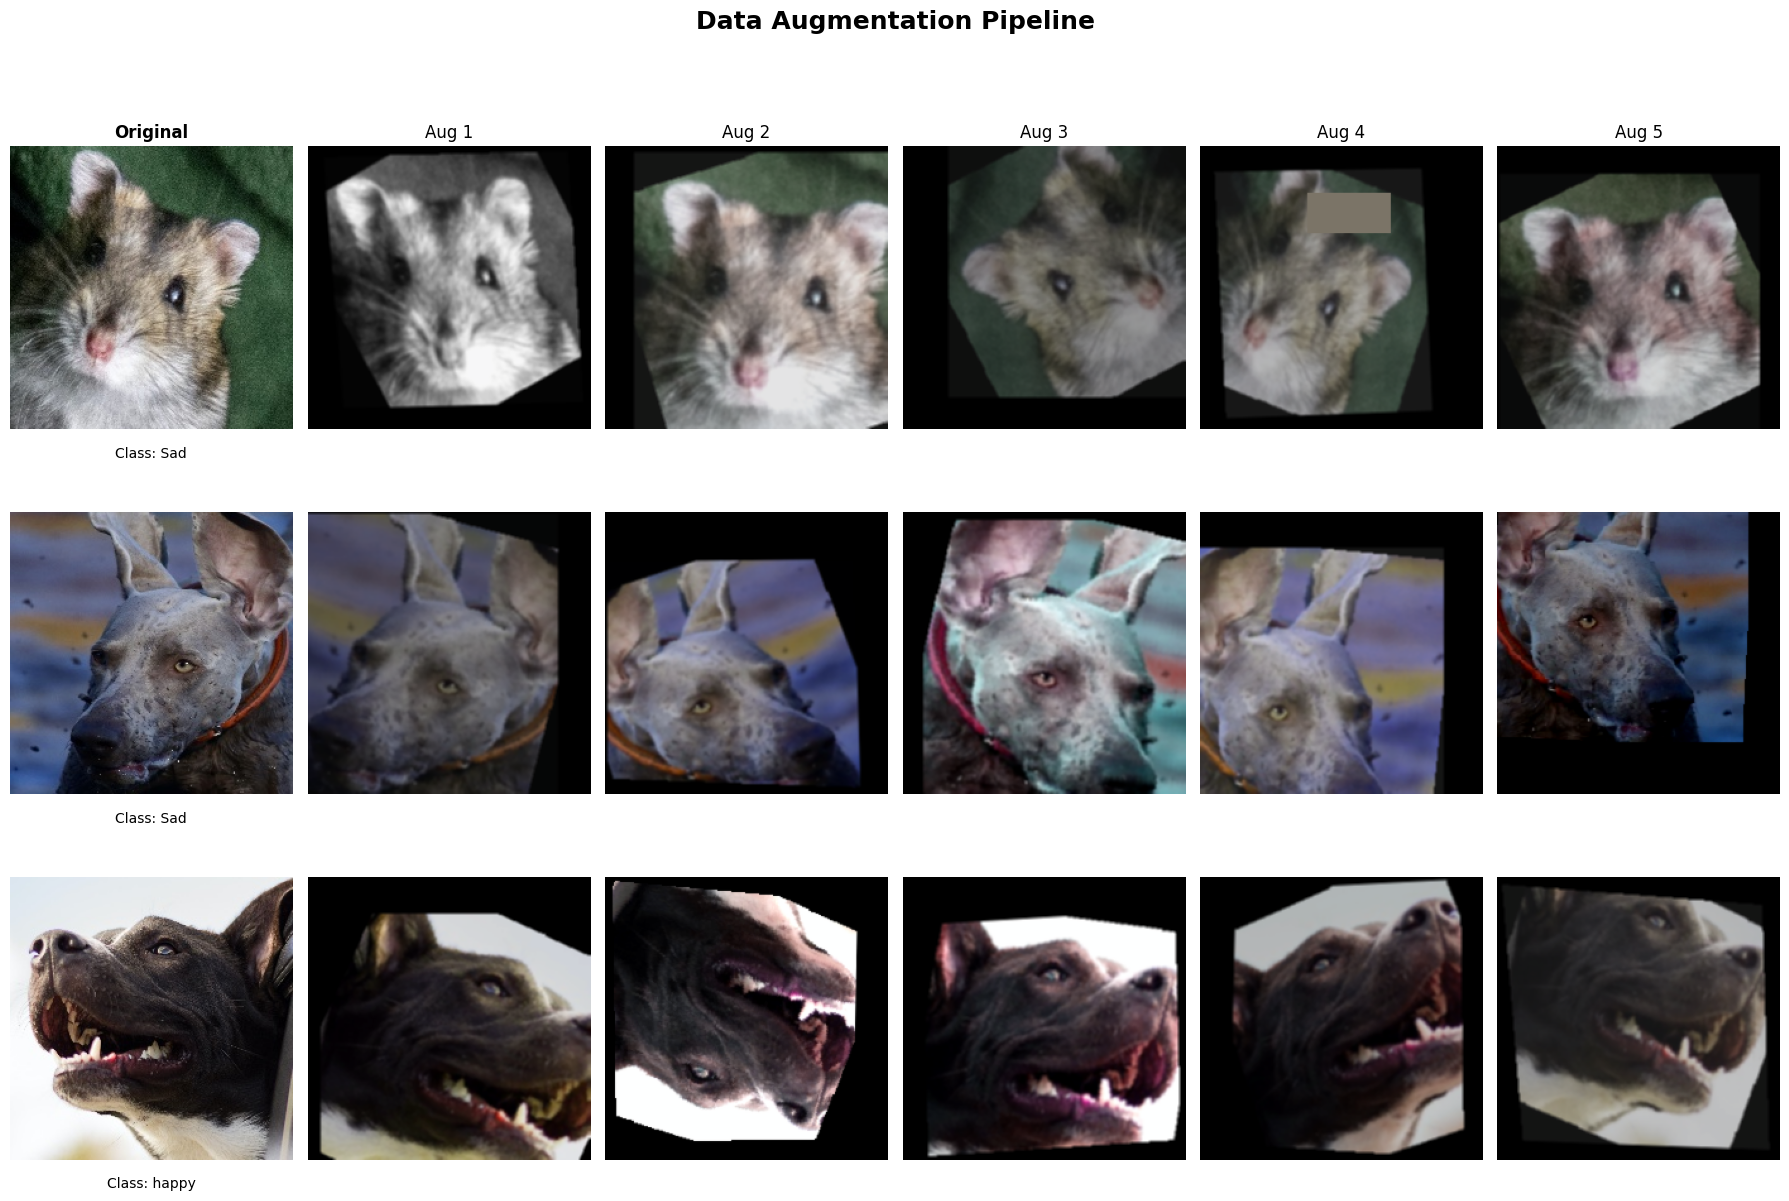

In [31]:
def visualize_augmentation_pipeline(dataset, num_samples=3):

    fig, axes = plt.subplots(num_samples, 6, figsize=(18, 4*num_samples))

    # Mean/std for denormalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for sample_idx in range(num_samples):

        # Actual index inside original ImageFolder
        real_idx = dataset.indices[sample_idx]

        # Access underlying ImageFolder
        base_dataset = dataset.dataset

        # Original image path
        original_path = base_dataset.samples[real_idx][0]

        from PIL import Image
        original_image = Image.open(original_path).convert('RGB')

        # Original image
        axes[sample_idx, 0].imshow(original_image)

        if sample_idx == 0:
            axes[sample_idx, 0].set_title(
                "Original",
                fontsize=12,
                fontweight='bold'
            )

        axes[sample_idx, 0].axis('off')

        class_idx = base_dataset.targets[real_idx]

        axes[sample_idx, 0].text(
            0.5,
            -0.1,
            f"Class: {base_dataset.classes[class_idx]}",
            transform=axes[sample_idx, 0].transAxes,
            ha='center',
            fontsize=10
        )

        # Show augmented versions
        for aug_idx in range(5):

            aug_image, _ = dataset[sample_idx]

            # Tensor -> numpy
            aug_np = aug_image.numpy().transpose(1, 2, 0)

            # Denormalize
            aug_np = std * aug_np + mean
            aug_np = np.clip(aug_np, 0, 1)

            axes[sample_idx, aug_idx + 1].imshow(aug_np)

            if sample_idx == 0:
                axes[sample_idx, aug_idx + 1].set_title(
                    f"Aug {aug_idx+1}",
                    fontsize=12
                )

            axes[sample_idx, aug_idx + 1].axis('off')

    plt.suptitle(
        "Data Augmentation Pipeline",
        fontsize=18,
        fontweight='bold',
        y=1.02
    )

    plt.tight_layout()
    plt.show()

visualize_augmentation_pipeline(train_dataset)

In [32]:
num_classes = len(train_dataset.dataset.classes)

print("Dataset sizes:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Test samples: {len(test_dataset)}")

print(f"Number of classes: {num_classes}")
print(f"Classes: {train_dataset.dataset.classes}")

Dataset sizes:
  Training samples: 700
  Validation samples: 150
  Test samples: 150
Number of classes: 4
Classes: ['Angry', 'Other', 'Sad', 'happy']
